In [ ]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv(
    "Road Accident Data.csv",
    nrows=100000
)
)
# ==========================================
# SHOW FIRST 5 ROWS
# ==========================================

print(df.head())

# ==========================================
# DATASET SHAPE
# ==========================================

print("\nDataset Shape:")
print(df.shape)

# ==========================================
# COLUMN NAMES
# ==========================================

print("\nColumn Names:")
print(df.columns)

# ==========================================
# DATASET INFO
# ==========================================

print("\nDataset Information:")
print(df.info())

# ==========================================
# CHECK MISSING VALUES
# ==========================================

print("\nMissing Values:")
print(df.isnull().sum())

In [ ]:
# ==========================================
# HANDLE MISSING VALUES
# ==========================================

# Fill missing values using most frequent value (mode)

for col in df.columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# ==========================================
# CHECK AGAIN
# ==========================================

print("Missing Values After Cleaning:\n")

print(df.isnull().sum())

In [ ]:
# ==========================================
# ENCODING CATEGORICAL COLUMNS
# ==========================================

from sklearn.preprocessing import LabelEncoder

# Create encoder object
le = LabelEncoder()

# Convert all object/text columns into numbers
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# ==========================================
# SHOW FIRST 5 ROWS AFTER ENCODING
# ==========================================

print(df.head())

In [ ]:
# ==========================================
# SEPARATE FEATURES AND TARGET
# ==========================================

# X = input features
X = df.drop("Accident_severity", axis=1)

# y = target/output
y = df["Accident_severity"]

# ==========================================
# DISPLAY SHAPES
# ==========================================

print("Feature Shape:", X.shape)

print("Target Shape:", y.shape)


In [ ]:
# ==========================================
# TRAIN TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# DISPLAY SHAPES
# ==========================================

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

In [ ]:
# ==========================================
# LOGISTIC REGRESSION MODEL
# ==========================================

from sklearn.linear_model import LogisticRegression

# Create model
lr = LogisticRegression(max_iter=5000)
# Train model
lr.fit(X_train, y_train)

# ==========================================
# MAKE PREDICTIONS
# ==========================================

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# ==========================================
# CHECK MODEL ACCURACY
# ==========================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.8376623376623377


In [ ]:
# ==========================================
# DECISION TREE MODEL
# ==========================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create model
dt = DecisionTreeClassifier(random_state=42)

# Train model
dt.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7633928571428571


In [ ]:
# ==========================================
# RANDOM FOREST MODEL
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8405032467532467


In [ ]:
# ==========================================
# SVM MODEL
# ==========================================

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Create model
svm = SVC()

# Train model
svm.fit(X_train, y_train)

# Predictions
y_pred_svm = svm.predict(X_test)

# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8376623376623377


In [ ]:
# ==========================================
# XGBOOST MODEL
# ==========================================

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Create model
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

# Train model
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Accuracy
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_accuracy)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:43:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8506493506493507


In [ ]:
# ==========================================
# MODEL COMPARISON TABLE
# ==========================================

import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy,
        svm_accuracy,
        xgb_accuracy
    ]
})

# Sort by best accuracy
results = results.sort_values(by="Accuracy", ascending=False)

print(results)

                 Model  Accuracy
4              XGBoost  0.850649
2        Random Forest  0.840503
0  Logistic Regression  0.837662
3                  SVM  0.837662
1        Decision Tree  0.763393


In [ ]:
# ==========================================
# SAVE BEST MODEL (XGBOOST)
# ==========================================

import pickle

# Save model
with open("best_model.pkl", "wb") as file:
    pickle.dump(xgb, file)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
# ==========================================
# LOAD SAVED MODEL
# ==========================================

import pickle

# Load model
with open("best_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
# ==========================================
# MAKE PREDICTION USING LOADED MODEL
# ==========================================

# Take first test sample
sample = X_test.iloc[0]

# Convert into proper shape
sample_input = [sample]

# Predict
prediction = loaded_model.predict(sample_input)

# ==========================================
# DISPLAY RESULT
# ==========================================

print("Predicted Severity:", prediction[0])

print("Actual Severity:", y_test.iloc[0])

Predicted Severity: 2
Actual Severity: 2


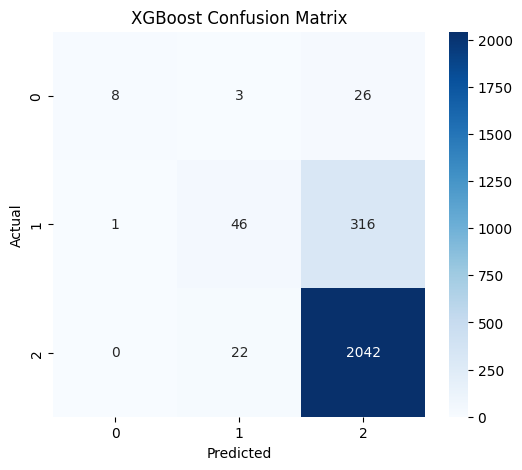

In [ ]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

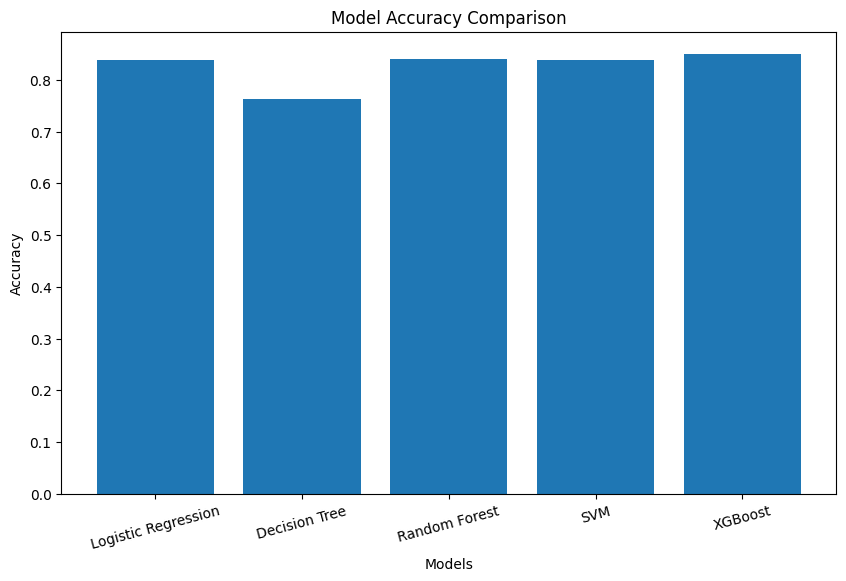

In [ ]:
# ==========================================
# MODEL ACCURACY COMPARISON GRAPH
# ==========================================

import matplotlib.pyplot as plt

# Model names
models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "SVM",
    "XGBoost"
]

# Accuracy values
accuracies = [
    accuracy,
    dt_accuracy,
    rf_accuracy,
    svm_accuracy,
    xgb_accuracy
]

# Create graph
plt.figure(figsize=(10,6))

plt.bar(models, accuracies)

# Labels
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

# Rotate labels
plt.xticks(rotation=15)

# Show graph
plt.show()

In [ ]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred_xgb
)

print(report)

              precision    recall  f1-score   support

           0       0.89      0.22      0.35        37
           1       0.65      0.13      0.21       363
           2       0.86      0.99      0.92      2064

    accuracy                           0.85      2464
   macro avg       0.80      0.44      0.49      2464
weighted avg       0.83      0.85      0.81      2464



In [ ]:
# ==========================================
# SAVE MODEL RESULTS
# ==========================================

results.to_csv("model_results.csv", index=False)

print("Model results saved successfully!")

Model results saved successfully!


In [ ]:
!pip install streamlit


In [ ]:
%%writefile app.py

import streamlit as st
import pickle
import pandas as pd

# ==========================================
# LOAD MODEL
# ==========================================

with open("best_model.pkl", "rb") as file:
    model = pickle.load(file)

# ==========================================
# TITLE
# ==========================================

st.title("🚦 Accident Severity Prediction System")

st.write("Enter accident details to predict severity.")

# ==========================================
# USER INPUTS
# ==========================================

time = st.text_input("Time")

day = st.text_input("Day of Week")

vehicles = st.text_input("Number of Vehicles")

casualties = st.text_input("Number of Casualties")

cause = st.text_input("Cause of Accident")

# ==========================================
# PREDICTION BUTTON
# ==========================================

if st.button("Predict Severity"):

    input_data = pd.DataFrame([[
        int(time),
        int(day),
        0,0,0,0,0,0,0,0,
        0,0,0,0,0,0,0,0,0,
        int(vehicles),
        int(casualties),
        0,0,0,0,0,0,0,0,
        int(cause)
    ]])

    prediction = model.predict(input_data)

    st.success(f"Predicted Severity: {prediction[0]}")

Writing app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙

2026-05-26 06:43:15.060 Uvicorn server started on 0.0.0.0:8503

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8503
  Network URL: http://172.28.0.12:8503
  External URL: http://35.252.182.34:8503

your url is: https://angry-months-own.loca.lt


In [ ]:
!npm install localtunnel

In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!npx localtunnel --port 8501

In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!npx localtunnel --port 8501

In [ ]:
from google.colab import files

files.download("best_model.pkl")